In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyETo

from pyETo import helpers
from pyETo.helpers import calc_es_ea, calc_gamma, calc_pressure, calc_delta, convert_energy

: 

## Hargreaves method

Hargreaves ETo (mm/day):
   DOY  Tmax  Tmin   Latitude  ETo_Hargreaves
0  218  38.3  23.4  37.365886        6.778599
1  219  38.4  23.5  37.365886        6.767789
2  220  38.5  23.6  37.365886        6.756378
3  221  38.6  23.7  37.365886        6.744366
4  222  38.7  23.8  37.365886        6.731752


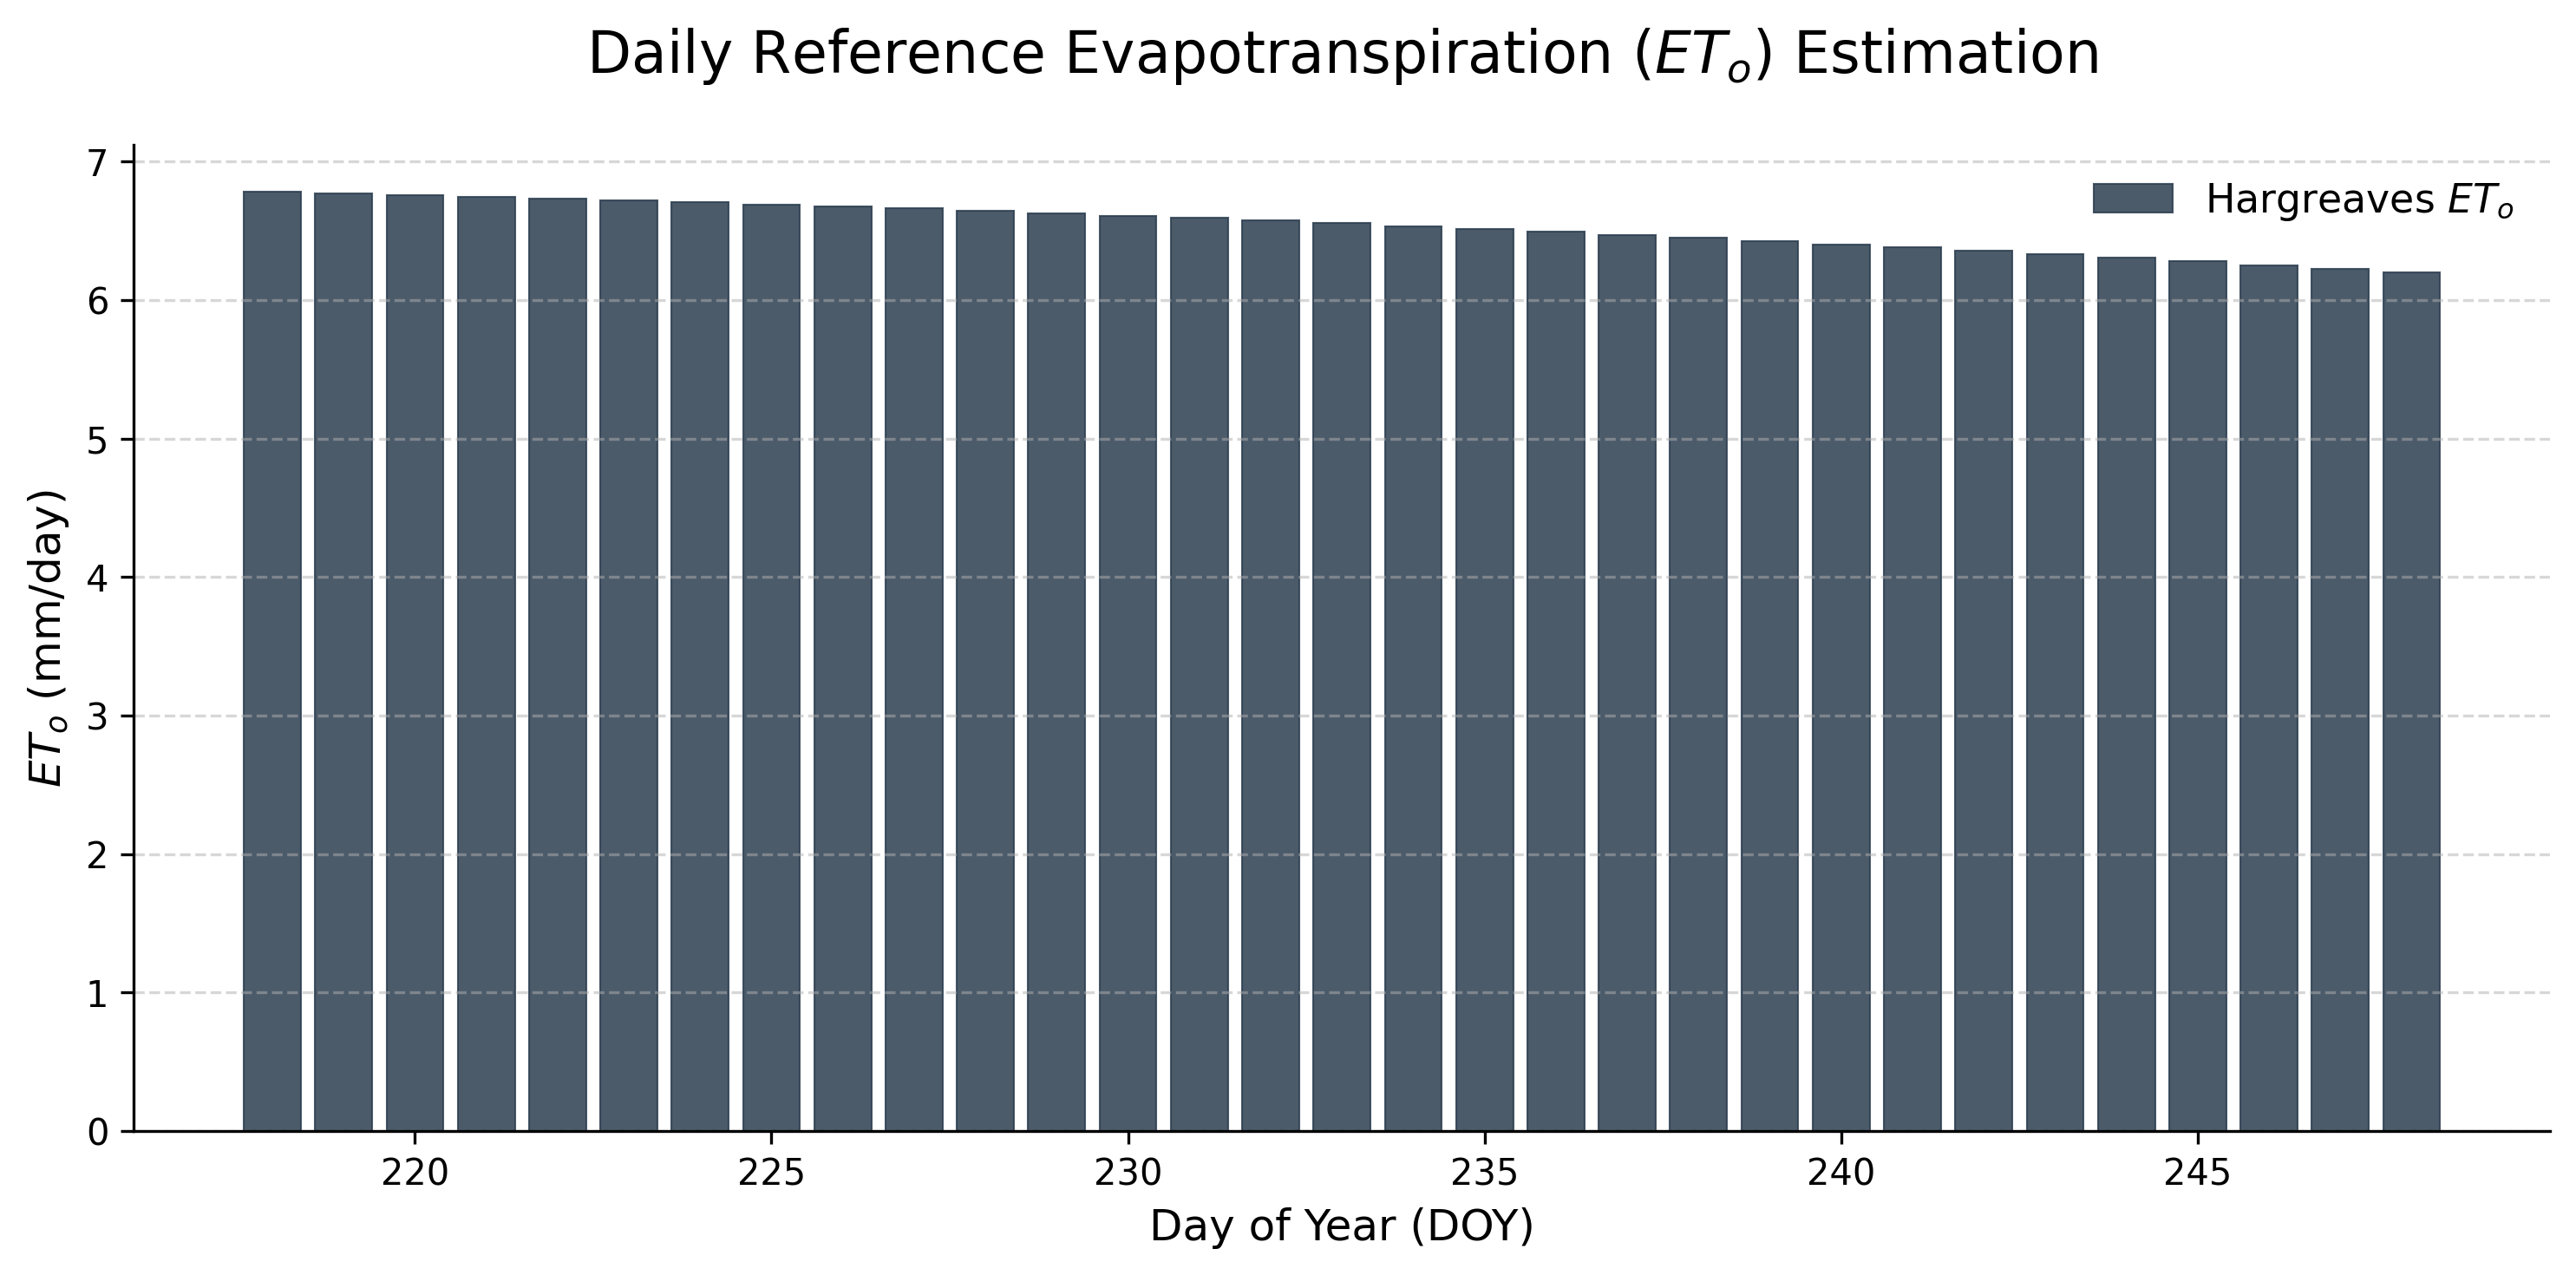

In [ ]:
file_path = r"C:\GitHub\py-eto\examples\data\sample_weather.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

df['ETo_Hargreaves'] = py_eto.hargreaves(
    t_min=df['Tmin'],
    t_max=df['Tmax'],
    latitude=df['Latitude'],
    doy=df['DOY'],
    year=2025
)
print("Hargreaves ETo (mm/day):")
print(df[['DOY', 'Tmax', 'Tmin', 'Latitude', 'ETo_Hargreaves']].head())

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
ax.bar(df['DOY'], df['ETo_Hargreaves'], 
       color='#2c3e50',          
       alpha=0.85,               
       width=0.8,                
       edgecolor='#2c3e50',      
       linewidth=0.5,
       label='Hargreaves $ET_o$')

ax.set_title('Daily Reference Evapotranspiration ($ET_o$) Estimation', 
             fontsize=16, pad=20)
ax.set_xlabel('Day of Year (DOY)', fontsize=12)
ax.set_ylabel('$ET_o$ (mm/day)', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

## PM daily

In [15]:
file_path = r"C:\GitHub\py-eto\examples\data\sample_weather.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet2')
display(df.head())

,Year,DOY,Latitude,Elevation,Tmax,Tmin,RH_max,RH_min,u2,T,RH,G,Rn
0,2025,218,37.365886,65,38.3,23.4,71.3,25.3,1.5,29.8,46.3,0,4520
1,2025,219,37.365886,65,38.4,23.5,71.2,25.2,1.7,29.9,46.2,0,4520
2,2025,220,37.365886,65,38.5,23.6,71.1,25.1,1.3,30.0,46.1,0,4520
3,2025,221,37.365886,65,38.6,23.7,71.0,25.0,2.1,30.1,46.0,0,4520
4,2025,222,37.365886,65,38.7,23.8,70.9,24.9,1.1,30.2,45.9,0,4520


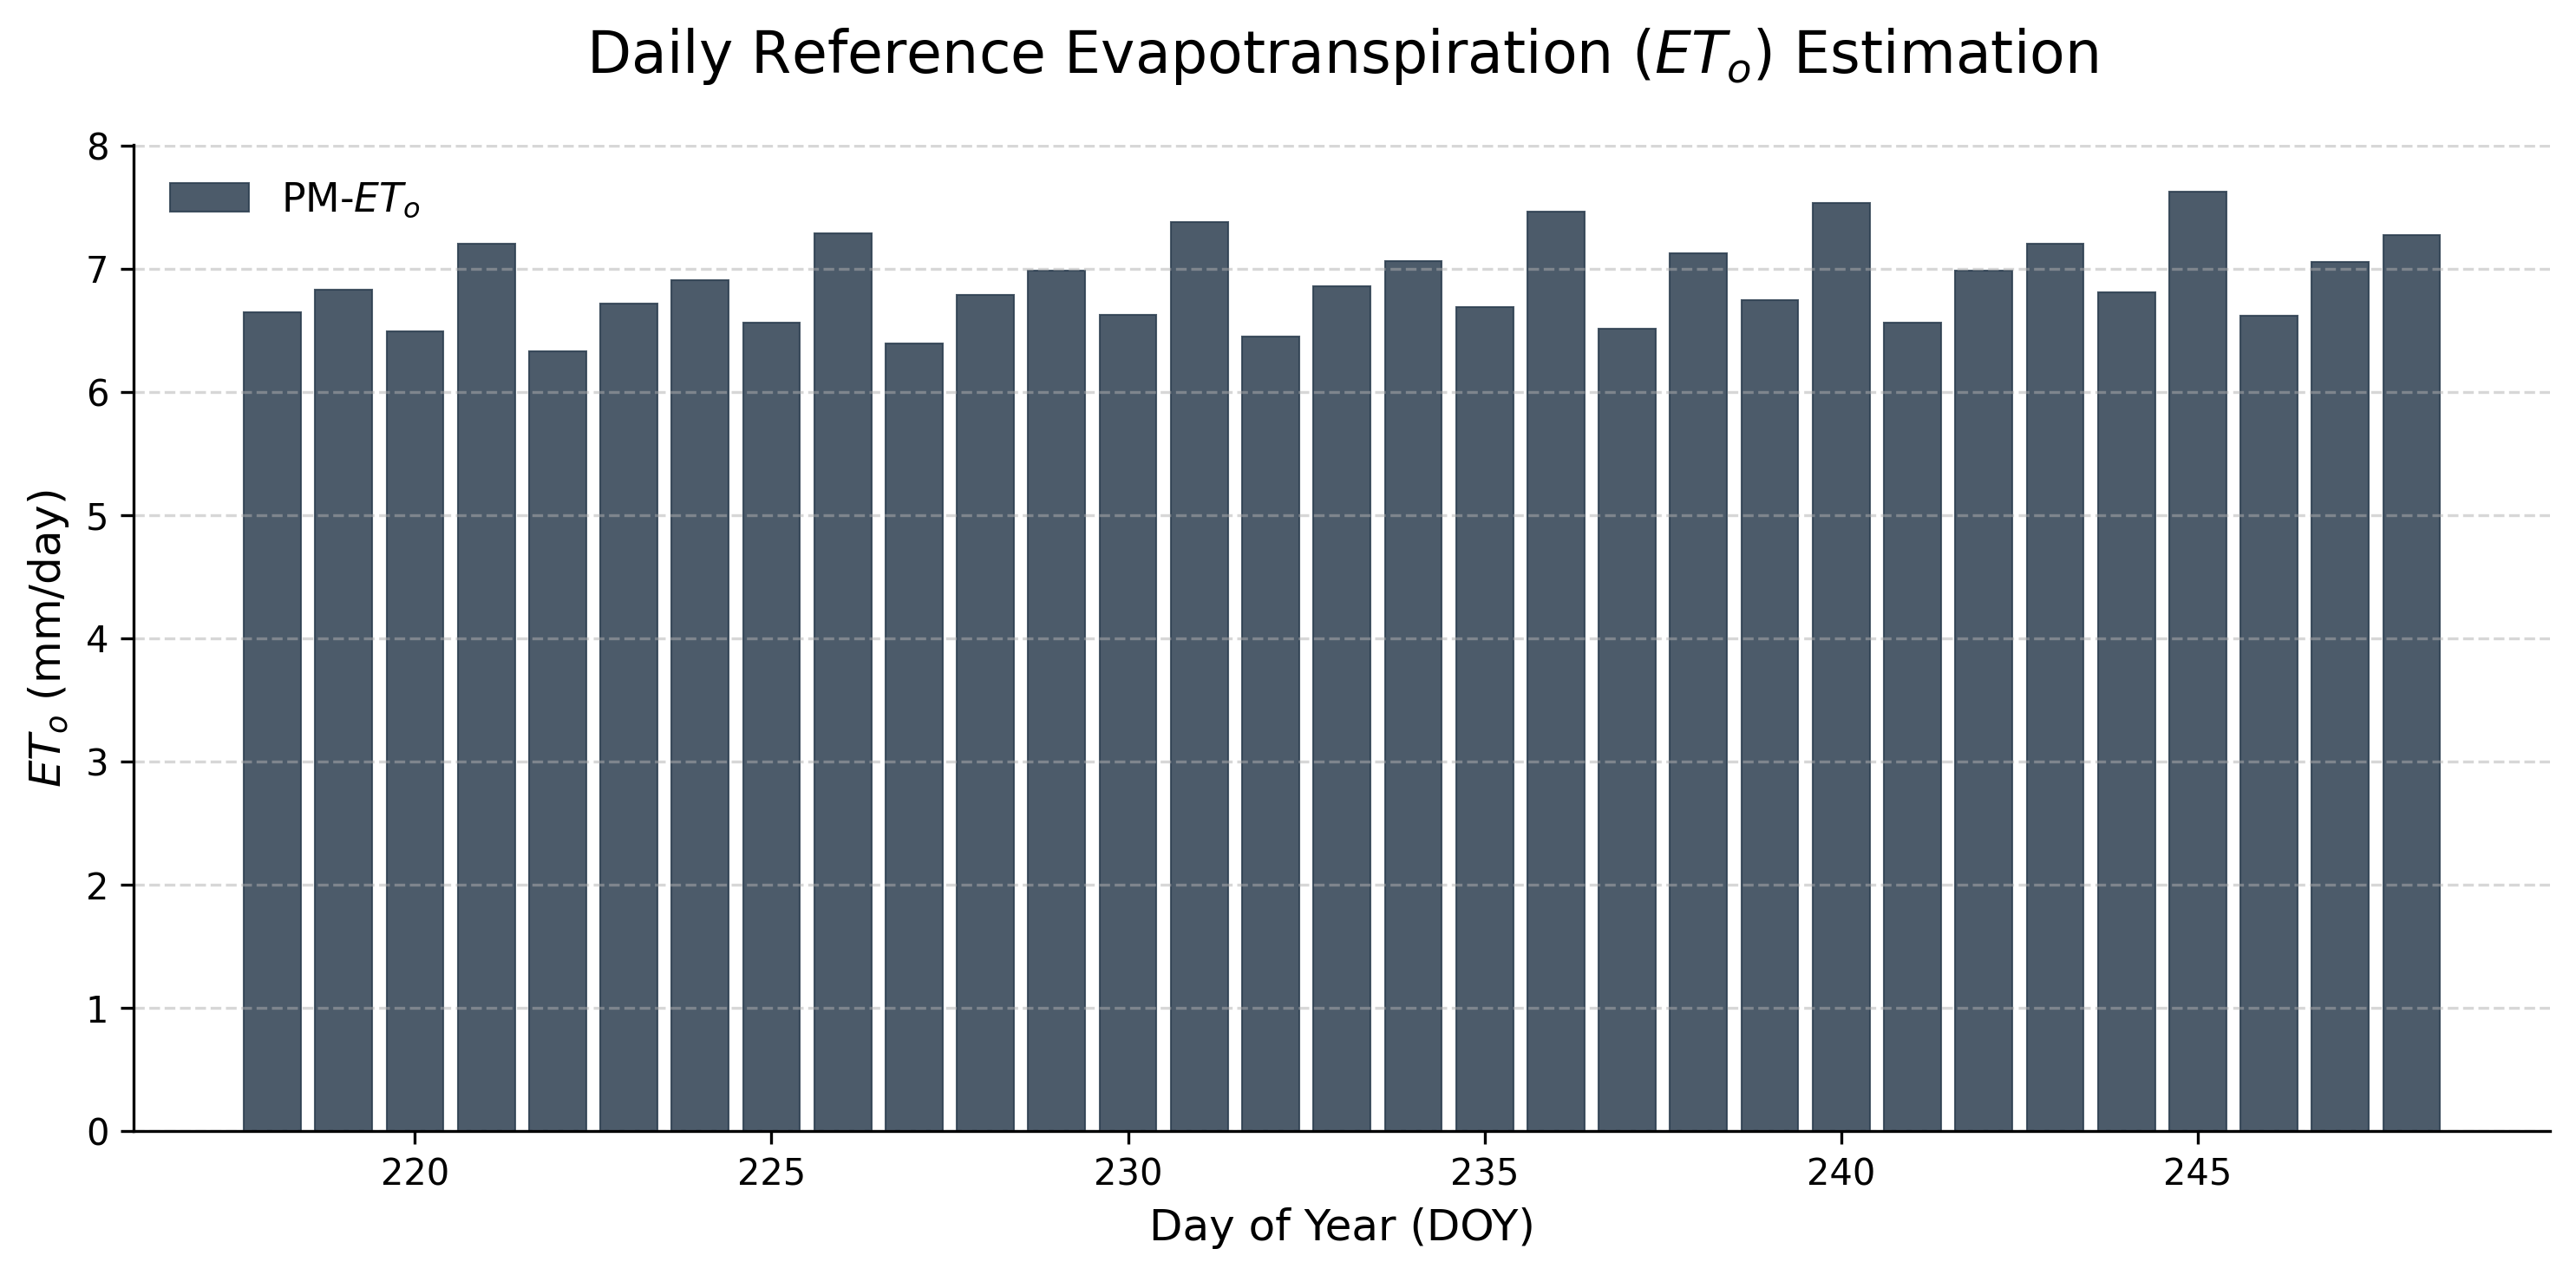

In [17]:
df['ETo_PM_Daily'] = py_eto.pm_daily(
    t_mean=df['T'], 
    u2=df['u2'], 
    rn=convert_energy(df['Rn']),
    g=df['G'], 
    es=calc_es_ea(df['T'], df['RH'])[0], 
    ea=calc_es_ea(df['T'], df['RH'])[1],
    delta=calc_delta(df['T']),
    gamma=calc_gamma(calc_pressure(df['Elevation']), t_mean=df['T']),
    reference='short',
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
ax.bar(df['DOY'], df['ETo_PM_Daily'], 
       color='#2c3e50',          
       alpha=0.85,               
       width=0.8,                
       edgecolor='#2c3e50',      
       linewidth=0.5,
       label='PM-$ET_o$')

ax.set_title('Daily Reference Evapotranspiration ($ET_o$) Estimation', 
             fontsize=16, pad=20)
ax.set_xlabel('Day of Year (DOY)', fontsize=12)
ax.set_ylabel('$ET_o$ (mm/day)', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

## PM hourly

In [11]:
file_path = r"C:\GitHub\py-eto\examples\data\sample_weather.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet3')

elevation = 65
df['rh_hr'] = df['Actual Vapor Pressure'] / df['Saturation Vapor Pressure'] * 100
df['Elevation'] = elevation
display(df.head())

,Year,Month,Day,Hour,Minute,DOY,TOD,DEC,u2,Wind\nDirection,...,G,H,LE,CO2\nFlux,ustar,Surface\nTemp,Soil\nTemp,Soil \nMoisture\nContent,rh_hr,Elevation
0,2020,8,15,0,30,228,0.5,228.02083,0.28,120.6,...,-30.78,1.26,1.13,0.0342,0.0536,21.66,27.45,0.080,85.018727,65
1,2020,8,15,1,30,228,1.5,228.06250,0.43,29.5,...,-30.93,1.02,1.19,0.0127,0.0415,21.12,26.91,0.080,82.954545,65
2,2020,8,15,2,30,228,2.5,228.10417,0.46,346.4,...,-30.43,-1.95,3.50,0.1291,0.0649,20.67,26.39,0.080,80.228137,65
3,2020,8,15,3,30,228,3.5,228.14583,0.54,201.0,...,-29.55,-3.11,1.98,0.1523,0.0478,20.35,25.96,0.079,85.425101,65
4,2020,8,15,4,30,228,4.5,228.18750,0.34,118.3,...,-28.28,-2.69,-1.16,0.1997,0.1000,19.95,25.58,0.079,86.666667,65


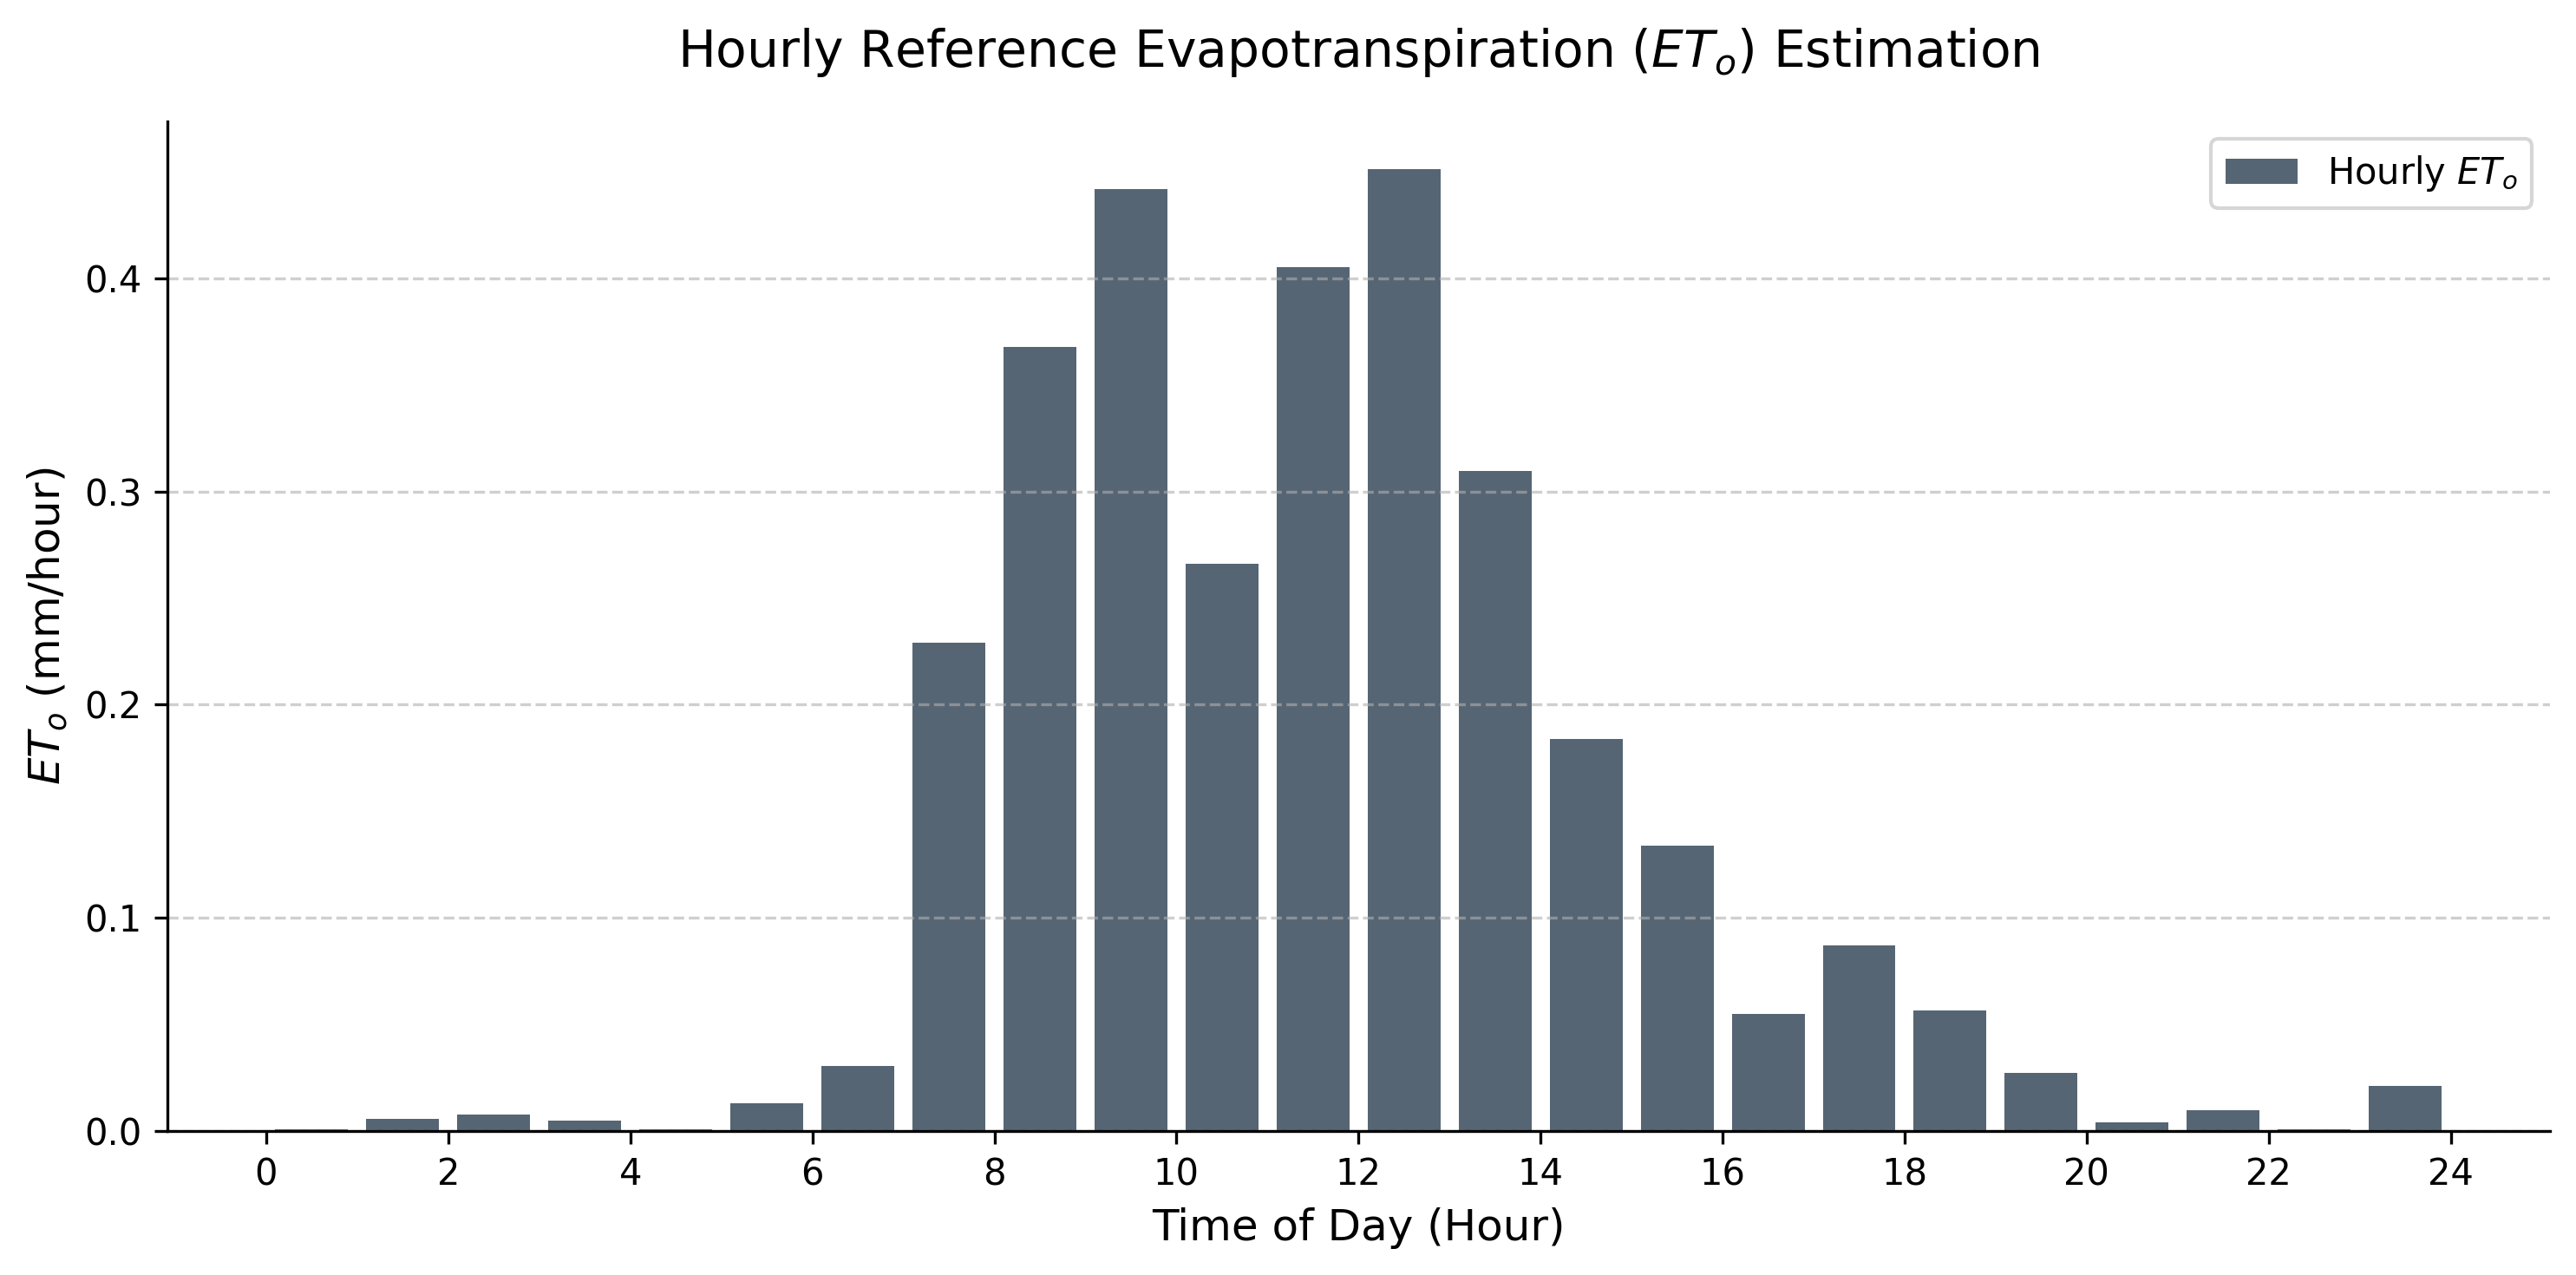

In [14]:
df['ETo_PM_Hourly'] = py_eto.pm_hourly(
    t_hr=df['T'], 
    u2_hr=df['u2'], 
    rn_hr=convert_energy(df['Rn']),
    es_hr=calc_es_ea(df['T'], df['rh_hr'])[0],
    ea_hr=calc_es_ea(df['T'], df['rh_hr'])[1],
    delta_hr=calc_delta(df['T']),
    gamma_hr=calc_gamma(calc_pressure(df['Elevation']), t_mean=df['T']),
    g_hr=convert_energy(df['G']), 
    reference='short',
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
plt.bar(df['TOD'], df['ETo_PM_Hourly'], 
        color='#2c3e50', alpha=0.8, width=0.8, 
        label='Hourly $ET_o$')

# Adjusting
plt.ylabel('$ET_o$ (mm/hour)', fontsize=12)
plt.xlabel('Time of Day (Hour)', fontsize=12)
plt.title('Hourly Reference Evapotranspiration ($ET_o$) Estimation', fontsize=14, pad=15)

# Setting up details
plt.xticks(range(0, 25, 2))  # Show x-axis value every 2 hr
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()